# W05A - Entropy of a finite harmonic-oscillator heat bath

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import gammaln
from scipy.special import factorial
from math import log as mathlog # why not use np.log ?
from numpy import log as npln

N = 100000                       # Try larger values
N_minus_1_fac = factorial(N-1, exact=True)
#print(N_minus_1_fac)
print(mathlog(N_minus_1_fac))
#print(npln(N_minus_1_fac))
print(gammaln(N))

1051287.7089736569
1051287.7089736569


np.log does not work because it tries to convert a huge integer to float, which only works for intergers up to 2**64

In [3]:
kb = 1; hbar_omega = 1; delta_E = 1

def get_entropy(E, N):
    return kb * ((N - 1) * np.log(E) \
           - gammaln(N)
           - N * np.log(hbar_omega) \
           + np.log(delta_E))

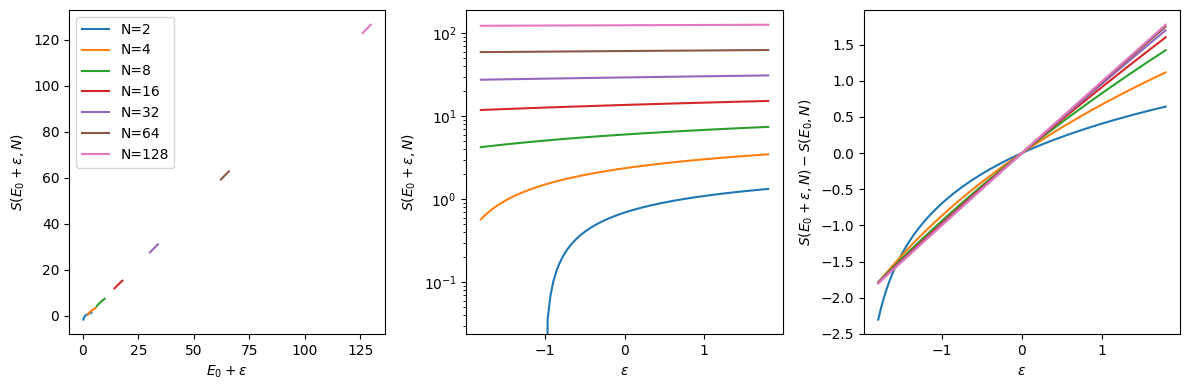

In [4]:
Ns = [2, 4, 8, 16, 32, 64, 128]
u = 1 #energy per oscillator fixed

fig, axes = plt.subplots(1,3, figsize=(12,4))

for N in Ns:
    E0 = N*u
    eps = np.linspace(-1.8, 1.8, 100)
    entropy = get_entropy(E0, N)
    eps_entropy = get_entropy(E0+eps, N)
    # axes[0].plot(E0+eps, [entropy]*100, label=f'N={N}')
    axes[0].plot(E0+eps, eps_entropy, label=f'N={N}')
    axes[1].plot(eps, eps_entropy)
    # axes[1].plot(eps, [entropy]*100)
    axes[2].plot(eps, eps_entropy-[entropy]*100)

axes[0].legend()
axes[0].set_ylabel(r'$S(E_0+\varepsilon,N)$')
axes[1].set_ylabel(r'$S(E_0+\varepsilon,N)$')
axes[2].set_ylabel(r'$S(E_0+\varepsilon,N)-S(E_0,N)$')

axes[0].set_xlabel(r'$E_0+\varepsilon$')
axes[1].set_xlabel(r'$\varepsilon$')
axes[2].set_xlabel(r'$\varepsilon$')

# axes[0].set_yscale('log')
# axes[0].set_xscale('log')
axes[1].set_yscale('log')

fig.tight_layout()
    


We see as N increases, the variation in entropy decreases. Especially the right-most figure shows that the entropy of a large bath (large N) gets increasingly linear.

### Task 3

Convince yourself that you ended up plotting the linear, quadratic and higher-order terms in the
Taylor expansion of the entropy for different bath sizes.

???

### Task 4

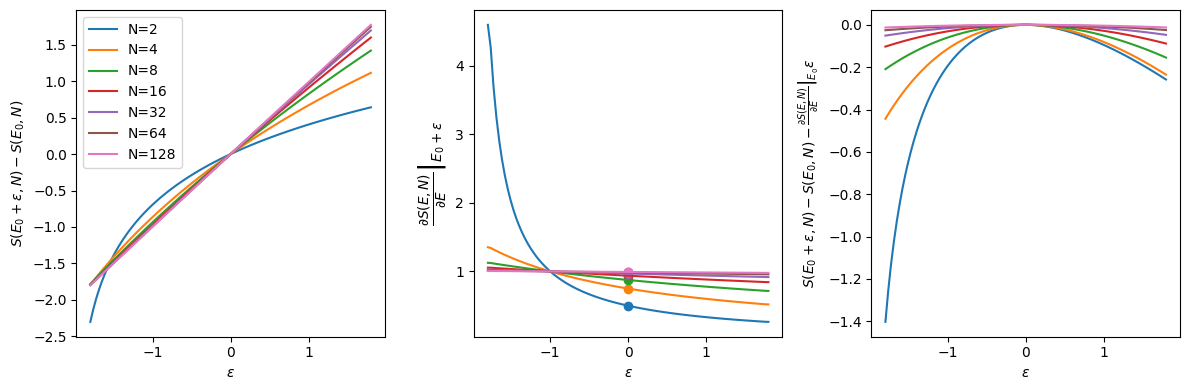

In [5]:
Ns = [2, 4, 8, 16, 32, 64, 128]
u = 1 #energy per oscillator fixed

fig, axes = plt.subplots(1,3, figsize=(12,4))

for N in Ns:
    E0 = N*u
    eps = np.linspace(-1.8, 1.8, 100)
    entropy = get_entropy(E0, N)
    eps_entropy = get_entropy(E0+eps, N)

    # eps_mids = (eps[:-1]+eps[1:])/2
    # dSdE = (eps_entropy[1:]-eps_entropy[:-1])/(eps_mids[1:]-eps_mids[:-1])
    # dSdE = np.diff(eps_entropy) / np.diff(eps)

    # numerical estimate of the gradient with np.gradient around E0+eps
    dSdE_E0_eps = np.gradient(eps_entropy, eps)

    # numerical estimate of the gradient with the central finite difference formula around E0
    h = 1e-5
    dSdE_E0 = (get_entropy(E0 + h, N) - get_entropy(E0 - h, N)) / (2*h)

    # the 2nd and higher order terms of the entropy (calculated from taylor expansion)
    higher_terms = eps_entropy - [entropy]*100 - dSdE_E0*eps

    axes[0].plot(eps, eps_entropy-[entropy]*100, label=f'N={N}')
    axes[1].plot(eps, dSdE_E0_eps)
    axes[1].scatter(0, dSdE_E0)
    axes[2].plot(eps, higher_terms)

axes[0].legend()

axes[0].set_ylabel(r'$S(E_0+\varepsilon,N)-S(E_0,N)$')
axes[1].set_ylabel(r'$\left.\frac{\partial S(E,N)}{\partial E}\right|_{E_0+\varepsilon}$', size=14)
axes[2].set_ylabel(r'$S(E_0+\varepsilon,N)-S(E_0,N)-\left.\frac{\partial S(E,N)}{\partial E}\right|_{E_0}\varepsilon$')

for ax in axes:
    ax.set_xlabel(r'$\varepsilon$')

fig.tight_layout()
    

We see that the gradient approaches a constant (1) as N increases, implying a greater linearity as N increases. On the right figure, we notice that the 2nd and higher-order terms go toward 0 as N increases, thereby showing the entropy in a large bath gets increasingly linear.

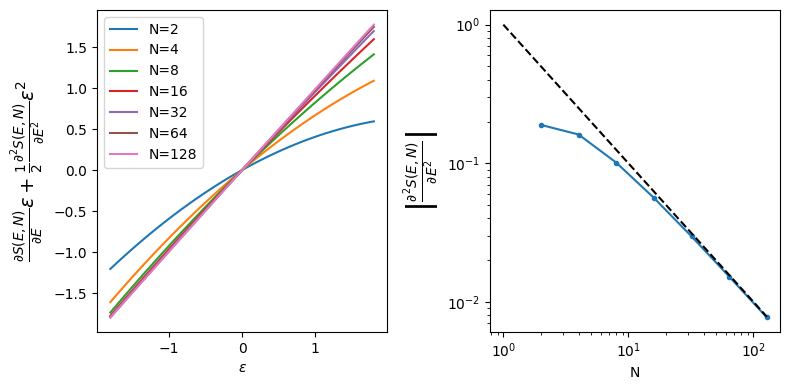

In [7]:
eps0 = 1

Ns = [2, 4, 8, 16, 32, 64, 128]
u = 1 #energy per oscillator fixed

fig, axes = plt.subplots(1,2, figsize=(8,4))

est_curvatures = []
for N in Ns:
    E0 = N*u
    eps = np.linspace(-1.8, 1.8, 100)

    # numerical estimate of the gradient with the central finite difference formula around E0
    h = eps0/100
    dSdE_E0 = (get_entropy(E0 + h, N) - get_entropy(E0 - h, N)) / (2*h)
    dS2dE2_E0 = 2*(get_entropy(E0+eps0, N) - get_entropy(E0,N) - dSdE_E0*eps0)

    lin_quad = dSdE_E0*eps + 1/2*dS2dE2_E0*eps**2
    est_curvatures.append(abs(dS2dE2_E0))

    axes[0].plot(eps, lin_quad, label=f'N={N}')

nspace = np.linspace(1,128, 100)

axes[1].plot(Ns, est_curvatures, '.-')
axes[1].plot(nspace, 1/nspace, 'k--')

axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_yscale('log')

axes[0].set_ylabel(r'$\frac{\partial S(E,N)}{\partial E}\varepsilon + \frac{1}{2}\frac{\partial^2 S(E,N)}{\partial E^2}\varepsilon^2$', size=14)
axes[1].set_ylabel(r'$\left|\frac{\partial^2 S(E,N)}{\partial E^2}\right|$', size=14)
axes[0].set_xlabel(r'$\varepsilon$')
axes[1].set_xlabel('N')
fig.tight_layout()



We've isolated and calculated the derivative and the second derivative at E0 and E = E0 + eps0.

We use these constants and plot along the epsilon space.

On the left we now only plot the linear and quadratic term, and no longer the higher order terms, in contrast to earlier.

On the right, we plot the quadratic term and see as N increases, the quadratic term decreases as 1/N, as we would expect from the analytical deriviations from the lecture notes.

### Task 6 - repeat with $-1.8N\leq\varepsilon\leq1.8N$ but ensure $E_0+\varepsilon>0$

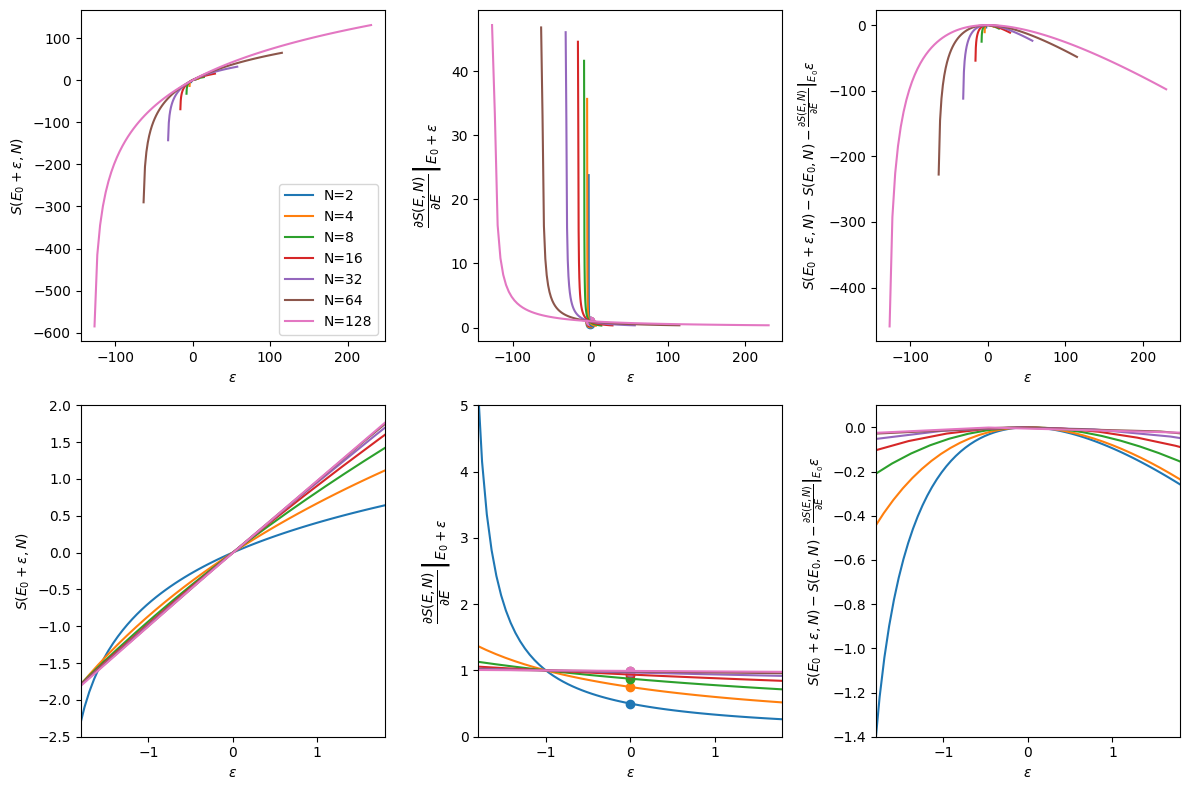

In [9]:
Ns = [2, 4, 8, 16, 32, 64, 128]
u = 1 #energy per oscillator fixed

fig, axes = plt.subplots(2,3, figsize=(12,8))

for N in Ns:
    E0 = N*u
    # eps = np.linspace(-1.8*N, 1.8*N, 100)

    # To fulfill the criterion, let eps > -E0, i.e. the minimum epsilon can be is -E0.
    eps = np.linspace(-0.99*E0, 1.8*N, 100)
    entropy = get_entropy(E0, N)
    E0_eps = E0+eps
    # E0_eps = np.maximum(E0_eps, 0)   # make negative values to 0
    eps_entropy = get_entropy(E0_eps, N)

    # numerical estimate of the gradient with np.gradient around E0+eps
    dSdE_E0_eps = np.gradient(eps_entropy, eps)

    # numerical estimate of the gradient with the central finite difference formula around E0
    h = 1e-5
    dSdE_E0 = (get_entropy(E0 + h, N) - get_entropy(E0 - h, N)) / (2*h)

    # the 2nd and higher order terms of the entropy (calculated from taylor expansion)
    higher_terms = eps_entropy - [entropy]*100 - dSdE_E0*eps

    for row in range(2):
        axes[row,0].plot(eps, eps_entropy-[entropy]*100, label=f'N={N}')
        axes[row,1].plot(eps, dSdE_E0_eps)
        axes[row,1].scatter(0, dSdE_E0)
        axes[row,2].plot(eps, higher_terms)

axes[0,0].legend()
axes[1,0].set_ylim(-2.5,2)
axes[1,1].set_ylim(0,5)
axes[1,2].set_ylim(-1.4,0.1)
for col in range(3):
    axes[1,col].set_xlim(-1.8,1.8)

for row in range(2):
    axes[row,0].set_ylabel(r'$S(E_0+\varepsilon,N)$')
    axes[row,1].set_ylabel(r'$\left.\frac{\partial S(E,N)}{\partial E}\right|_{E_0+\varepsilon}$', size=14)
    axes[row,2].set_ylabel(r'$S(E_0+\varepsilon,N)-S(E_0,N)-\left.\frac{\partial S(E,N)}{\partial E}\right|_{E_0}\varepsilon$')

for ax in axes.flatten():
    ax.set_xlabel(r'$\varepsilon$')


fig.tight_layout()
    

Over a growing interval, the entropy is not linear. However, if we zoom in to the same dimensions as the earlier exercise, we see that for large N, the curves are approximately linear. So, if the exchanged energies (range of epsilon) remain small compared to the total heat bath energy, we find an approximate linearity. 

This is because when epsilon is small compared to the total heat bath energy, the curvature of entropy over that small range, e.g. -1.8 to 1.8, is very small, so $\partial S/\partial E\approx 1$.

# W05B Microstates and macrostates for a 3x3 lattice

### Task 1

Covalent dimers: horizontally or vertically adjecent atoms (E=-1/2)

Van der Walls (vdW) dimers: diagonally adjecent atoms (E=-1/4)

Seperate atoms: no adjecent atoms (E=0)


**Covalent dimers:** 6 horizontal and 6 vertical adjecent configurations = 12

**vdW dimers:** 4 possible diagonal from left to right, and 4 possbile diagonal from right to left = 8

**Seperate atoms:** 36-12-8=16

$\$

$\sum_i P(s_i)=12/36+8/36+16/36=36/36=1$

$\langle E \rangle = 12/36\cdot(-1/2)+8/36\cdot(-1/4)+16/36\cdot(0)$

In [10]:
12/36*(-1/2)+8/36*(-1/4)+16/36*0

-0.2222222222222222

### Task 2

Only vdW dimers has a distribution

$\sum_i P(s_i)=12\cdot0+8\cdot1/8+16\cdot0=8/8=1$

$\langle E \rangle = 0\cdot(-1/2)+8\cdot1/8\cdot(-1/4)+0\cdot(0)=-1/4$

### Task 3

$\sum_i P(s_i)=12\cdot1/24+8\cdot0+16\cdot1/32=1/2+1/2=1$

$\langle E \rangle = 12/24\cdot(-1/2)+8\cdot0\cdot(-1/4)+16/32\cdot(0)=-1/4$

### Task 4

$P(s_i)=\frac{1}{Z}\exp(-\beta E(s_i)),$

$\beta=\frac{1}{k_b T} = 2\ln(4/3),$

$Z=\sum_i \exp(-\beta E(s_i))$

Now:

$Z=12\cdot\exp(\frac{1}{2}\beta)+8\cdot\exp(\frac{1}{4}\beta)+16\cdot\exp(0\beta)$

$Z = 12\cdot\frac{4}{3}+8\left(\frac{4}{3}\right)^{1/2}+16$


In [80]:
Z = 12*4/3 + 8*(4/3)**(1/2)+16
Z

41.23760430703401

$$\sum_i P(s_i)=\frac{1}{Z}\left(12\cdot\exp(\frac{1}{2}\beta)+8\cdot\exp(\frac{1}{4}\beta)+16\cdot\exp(0\beta)\right)=Z/Z=1$$

$$\langle E \rangle = \frac{12}{Z}\cdot\exp(\frac{1}{2}\beta)\cdot(-1/2)+\frac{8}{Z}\cdot\exp(\frac{1}{4}\beta)\cdot(-1/4)+\frac{16}{Z}\cdot(0)$$

$$= \frac{12}{Z}\cdot\frac{4}{3}\cdot(-1/2)+\frac{8}{Z}\cdot\left(\frac{4}{3}\right)^{1/2}\cdot(-1/4)+\frac{16}{Z}\cdot(0)$$

In [81]:
Eavg = 12/Z*4/3*(-1/2)+8/Z*(4/3)**(1/2)*(-1/4)+16/Z*0

beta = 2*np.log(4/3)
p0 = 1/Z * np.exp(1/2*beta)
p1 = 1/Z * np.exp(1/4*beta)
p2 = 1/Z * np.exp(0*beta)
print("Probabilites from Boltzmann distribtion at given kbT:"
      + f"\n{p0=:.3g}"
      + f"\n{p1=:.3g}"
      + f"\n{p2=:.3g}")
print("Average energy:", Eavg)

Probabilites from Boltzmann distribtion at given kbT:
p0=0.0323
p1=0.028
p2=0.0242
Average energy: -0.25


### Task 5

$S = -k_b \sum_i P(s_i)\ln P(s_i)$

Distribution from task 2:

$S = -k_b \left(0\ln0+8/8\ln(1/8)+0\ln0\right)=k_b\ln8\simeq 2.1k_b$

Distribution from task 3:

$S = -k_b \left(12/24\ln(1/24)+0\ln0+16/32\ln(1/32)\right)=k_b\left(1/2\ln24+1/2\ln32\right)\simeq3.3k_b$

Distribution from task 4:

$S = -\frac{k_b}{Z} \left(12\cdot\exp(\frac{1}{2}\beta)\ln(\frac{1}{Z}\exp(\frac{1}{2}\beta))+8\cdot\exp(\frac{1}{4}\beta)\ln(\frac{1}{Z}\exp(\frac{1}{4}\beta))+16\cdot\exp(0\beta)\ln(\frac{1}{Z}\exp(0\beta))\right)$

$= -\frac{k_b}{Z} \left(12\cdot\frac{4}{3}\cdot\left(\ln(4/3)-\ln(Z)\right)+8\cdot\left(\frac{4}{3}\right)^{1/2}\cdot\left(\frac{1}{2}\cdot\ln(4/3)-\ln(Z)\right)+16\cdot(-\ln(Z))\right)$


In [83]:
# 12*4/3+8*(4/3)**(1/2)

import numpy as np
print(-1/Z*(12*4/3*(np.log(4/3)-np.log(Z))+8*(4/3)**(1/2)*(1/2*np.log(4/3)-np.log(Z))+16*(-np.log(Z))))

3.575509529747472


$=-k_b(\frac{1}{2}\ln(4/3) - \ln(Z))\approx3.6k_b$

Using the Boltzmann distribution yields the largest entropy, illustrating its maximum-entropy property.

### Task 6 Maximize the entropy at a fixed average energy

$12p_0+8p_1+16p_2=1 \Leftrightarrow p_2 = \frac{1}{16}\left(1-12p_0-8p_1\right)$

For all probabilities to be non-negative, we must have $12p_0+8p_1\leq1$

$\langle E \rangle = 12p_0\cdot(-0.5)+8p_1\cdot(-0.25)+16p_2\cdot(0)=-6p_0-2p_1$

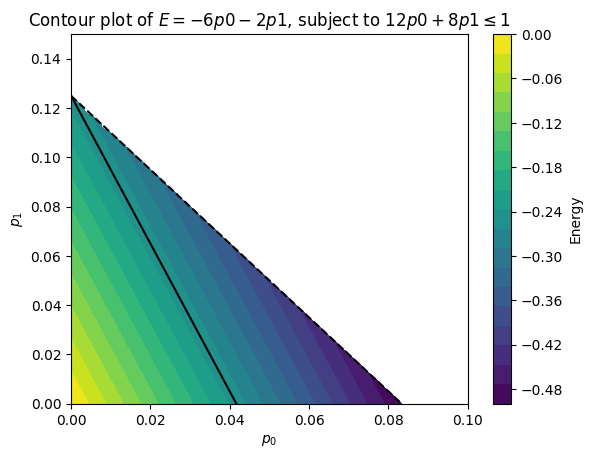

In [88]:
import numpy as np
import matplotlib.pyplot as plt

p0 = np.linspace(0, 1/12, 100)
p1 = np.linspace(0, 1/8, 100)

X, Y = np.meshgrid(p0, p1)
E = -6*X - 2*Y

constraint = 12*X + 8*Y <= 1
E[~constraint] = np.nan   #tilde reverses the mask, so everything that does fulfil the constraint are NaN.

levels = np.linspace(-0.5, 0, 20)
contours = plt.contourf(X, Y, E, levels=levels)

# Draw the boundary 12p0 + 8p1 = 1
plt.plot(p0, (1-12*p0)/8, 'k--')

# Draw E = -1/4 = -6p0 -2p1 <=> p1 = 1/8 - 3p0
plt.plot(p0, 1/8-3*p0, 'k')
# since p1 cannot be negative, 0 <= p0 <= 1/24

# Labels
plt.xlabel(r"$p_0$")
plt.ylabel(r"$p_1$")
plt.title(r"Contour plot of $E=-6p0-2p1$, subject to $12p0+8p1\leq1$")

# Colorbar
cbar = plt.colorbar(contours, label="Energy")
cbar.set_ticks(np.arange(-0.48, 0.0001, 0.06))
plt.xlim(0,0.10)
plt.ylim(0,0.15)
plt.show()

C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:4: RuntimeWarning: divide by zero encountered in log
  entropy = -12 * np.where(X>0, X*np.log(X), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:4: RuntimeWarning: invalid value encountered in multiply
  entropy = -12 * np.where(X>0, X*np.log(X), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:5: RuntimeWarning: divide by zero encountered in log
  -8 * np.where(Y>0, Y*np.log(Y), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:5: RuntimeWarning: invalid value encountered in multiply
  -8 * np.where(Y>0, Y*np.log(Y), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:6: RuntimeWarning: divide by zero encountered in log
  -16 * np.where(XY>0, XY*np.log(XY), 0)
C:\Users\emilk\AppData\Local\Temp\ipykernel_36476\2351736132.py:6: RuntimeWarning: invalid value encountered in log
  -16 * np.where(XY>0, XY*np.log(XY), 0)
C:\Users\emilk\AppData\Local\Te

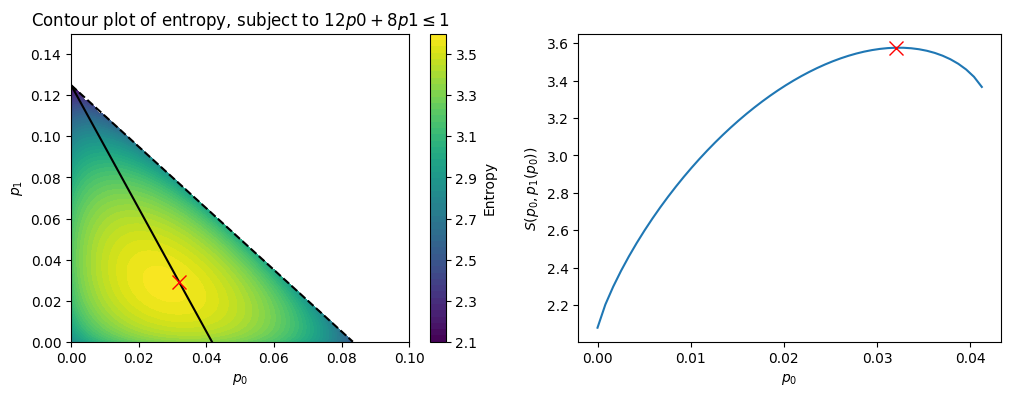

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

XY = (1-12*X-8*Y)/16
entropy = -12 * np.where(X>0, X*np.log(X), 0) \
          -8 * np.where(Y>0, Y*np.log(Y), 0) \
          -16 * np.where(XY>0, XY*np.log(XY), 0)

constraint = 12*X + 8*Y <= 1
entropy[~constraint] = np.nan   #tilde reverses the mask, so everything that does fulfil the constraint are NaN.

levels = np.linspace(2.1, 3.6, 50)
contours = axes[0].contourf(X, Y, entropy, levels=levels)

# Draw the boundary 12p0 + 8p1 = 1
axes[0].plot(p0, (1-12*p0)/8, 'k--')

# Draw E = -1/4 = -6p0 -2p1 <=> p1 = 1/8 - 3p0
axes[0].plot(p0, 1/8-3*p0, 'k')
# since p1 cannot be negative, 0 <= p0 <= 1/24. This has been masked out with the constraint.

# Labels
axes[0].set_xlabel(r"$p_0$")
axes[0].set_ylabel(r"$p_1$")
axes[0].set_title(r"Contour plot of entropy, subject to $12p0+8p1\leq1$")

# Colorbar
cbar = fig.colorbar(contours, label="Entropy")
cbar.set_ticks(np.arange(2.1, 3.6, 0.2))
axes[0].set_xlim(0,0.10)
axes[0].set_ylim(0,0.15)


p1_p0 = 1/8 - 3*p0
p2 = (1-12*p0-8*p1_p0)/16
restricted_entropy = -12 * np.where(p0>0, p0*np.log(p0), 0) \
                     -8 * np.where(p1_p0>0, p1_p0*np.log(p1_p0), 0) \
                     -16 * np.where(p2>0, p2*np.log(p2), 0)
# we must use a mask, like the constraint earlier, such that 0 <= p0 <= 1/24
mask = p0<=1/24
axes[1].plot(p0[mask], restricted_entropy[mask])
axes[1].set_xlabel(r"$p_0$")
axes[1].set_ylabel(r"$S(p_0, p_1(p_0))$")



# Now to determine the maximum entropy:
max_i = np.argmax(restricted_entropy[mask])
max_entropy = restricted_entropy[max_i]
p0_max = p0[max_i]
p1_max = 1/8 - 3*p0_max  # from our restriction when E=-1/4
p2_max = (1-12*p0_max-8*p1_max)/16

axes[0].plot(p0_max, p1_max, 'rx', ms=10)
axes[1].plot(p0_max, max_entropy, 'rx', ms=10)


In [91]:
print("Probabilites at maximum entropy with condition E=-1/4:"
      + f"\n{p0_max=:.3g}"
      + f"\n{p1_max=:.3g}"
      + f"\n{p2_max=:.3g}")

Probabilites at maximum entropy with condition E=-1/4:
p0_max=0.032
p1_max=0.029
p2_max=0.024


These values are very accurate with the one determined by the boltzmann distrubtion in Task 4.

In Task 6 we never used the boltzmann distribution, we simply aimed to maximize entropy numerically. We found the same results as computing via the boltzmann distribution, demonstrating the maximum-entropy property of the Boltzmann distribution. The Boltzmann distribution maximizes the Gibbs entropy subject to fixed normalization and fixed average
energy. 

In [92]:
print("Maximum entropy:", max_entropy)

Maximum entropy: 3.575312420741824


Compared with task 5, this is exactly right for the system at this temperature, i.e. at this average energy.

For the distribution where p0 = p2 = 0 means p1=1/8, which is the top-left corner of the entropy contour plot, where entropy seems to be lowest at S=2.1

For the distribution where p0 = 1/24, p1 = 0 and p2=1/32 is about half-way along the bottom of the contor plot, where entropy is pretty high, around S=3.3

# W05C Two macrostates for the harmonic oscillator

In [17]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1 - plot distributions

C:\Users\emilk\AppData\Local\Temp\ipykernel_6180\2596399343.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.where(abs(x) <= 2, 1/(np.pi*np.sqrt(4-x**2)), 0)


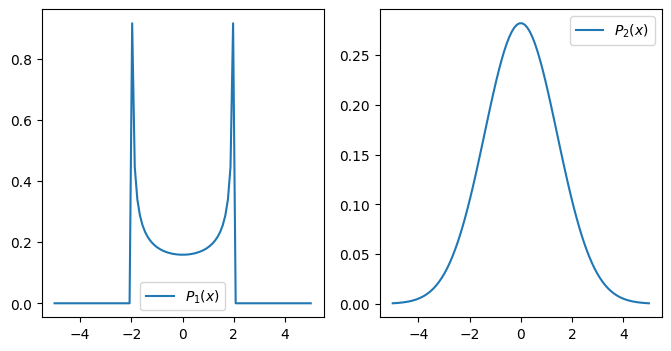

In [31]:
def p1(x):
    return np.where(abs(x) <= 2, 1/(np.pi*np.sqrt(4-x**2)), 0)

def p2(x, kbT=2):
    return 1/np.sqrt(2*np.pi*kbT) * np.exp(-x**2/(2*kbT))

def pot(x):
    return 1/2*x**2

xspace = np.linspace(-5,5, 100)

fig, axes = plt.subplots(1,2,figsize=(8,4))

axes[0].plot(xspace, p1(xspace), label=r'$P_1(x)$')
#axes[0].set_xlim(-2,2)
axes[1].plot(xspace, p2(xspace), label=r'$P_2(x)$')
for ax in axes:
    ax.legend()

The first one looks like a probability distribution of x-values for a harmonic oscillator with constant energy.

The second one looks like a probability distribution for a harmonic oscilator of changing energy (velocity), i.e. the boltzmann distribution of positions centered around x=0. It is a harmonic oscillator in a heat bath of constant temperature, and it is constantly exchanging energy with it which changes its velocity. The distribution we see is then the boltzmann distribution.

If we sample from the left figure with different velocities, we would gain the probability distribution on the right (exactly like week 4)

P1 is a *microcanonical ensemble*, a collection of states at constant energy.

P2 is a *canonical ensemble*, a collection of states at a constant temperature that can exchange energy with a heat bath.

In [33]:
from scipy.integrate import quad

res1, err1 = quad(p1, -2, 2)
print(f'{res1:.3f}')

res2, err2 = quad(p1, -10, 10)
print(f'{res2:.3f}')

1.000
1.000


C:\Users\emilk\AppData\Local\Temp\ipykernel_6180\2596399343.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.where(abs(x) <= 2, 1/(np.pi*np.sqrt(4-x**2)), 0)


Calculate average potential energy:

In [35]:
def P1V1(x):
    return p1(x)*pot(x)
def P2V2(x):
    return p2(x)*pot(x)

res1, err1 = quad(P1V1, -2, 2)
print(f'{res1:.3f}')

res2, err2 = quad(P2V2, -10, 10)
print(f'{res2:.3f}')

1.000
1.000


They are exactly the same.

For the boltzmann distribution, $<V>=1/2*k_bT = 1$

Calculate entropy:

In [38]:
def entropy1(x):
    return p1(x)*np.log(p1(x))
def entropy2(x):
    return p2(x)*np.log(p2(x))

s1, err1 = quad(entropy1, -2, 2)
print(f'{-s1:.3f}')

s2, err2 = quad(entropy2, -10, 10)
print(f'{-s2:.3f}')


1.145
1.766


When the oscillator just swings back and forth without exchanging energy, the macrostate can only explore the microstates compatible with that energy, and the entropy is low.

When it is allowed to exchange energy with a heat bath, the macrostate includes microstates at several energies, so entropy is maximized. This connects to the maximum-entropy property of the Boltzmann distribution.

If the unit of length is altered, the numerical value of the entropy would change. Probability has unit length, so writing P in meters vs. cm makes a difference in the integration, where the limits and dx change, and ln(P) would introduce a *shift* by a constant. However, it would not alter the comparisons and conclusions drawn above, because the same shift would occur in both integrals.

# W05D From enumeration to sampling in a finite configuration space

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 0, 'Energy, $E$')

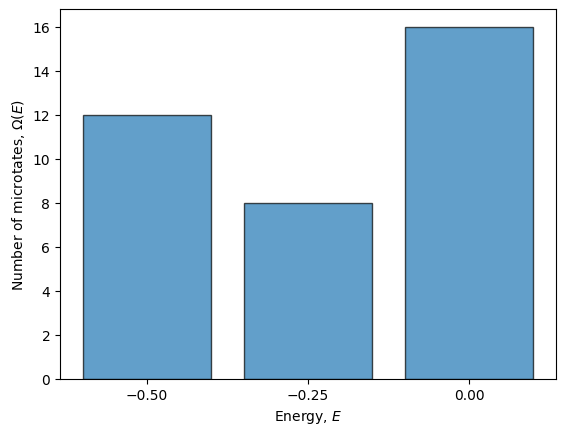

In [2]:
states = np.zeros(36)
states[0:12] = -1/2
states[12:20] = -1/4
states[20:36] = 0

fig, ax = plt.subplots()
ax.hist(states, bins=[-0.625, -0.375, -0.125, 0.125], rwidth=0.8, alpha=0.7, edgecolor='k')
ax.set_xticks([-1/2, -1/4, 0])
ax.set_ylabel(r'Number of microtates, $\Omega(E)$')
ax.set_xlabel(r'Energy, $E$')

In [3]:
#canonical average energy:
kbT = 0.25
E_avg = sum(states*np.exp(-states/kbT))/sum(np.exp(-states/kbT))
print(E_avg)

-0.3937106250885293


### Task 2

Number of microstates: 36


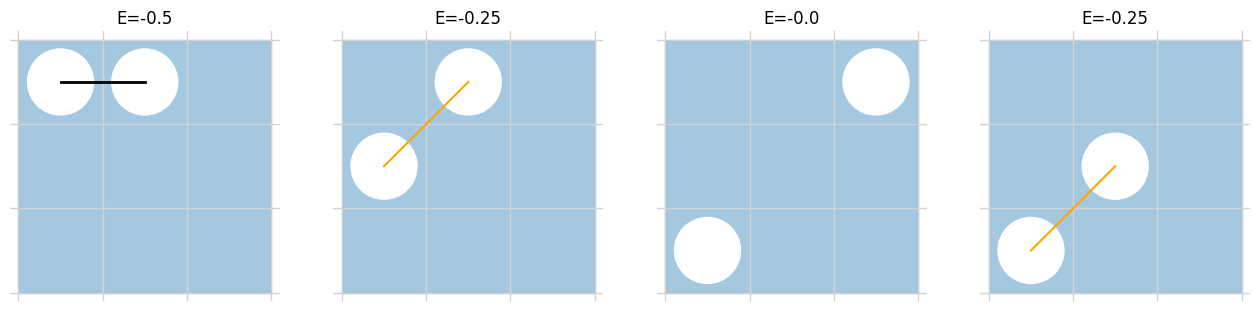

In [4]:
from week05 import make_microstate_factory
MicroState = make_microstate_factory(N=2, L=3)
print("Number of microstates:", MicroState.total)

fig, axes = plt.subplots(1,4,figsize=(16,4))
for i, ax in enumerate(axes):
    MicroState(i*9).plot(ax)
    ax.set_title(f'E={MicroState(i*9).energy}')

Text(0.5, 0, 'Energy, $E$')

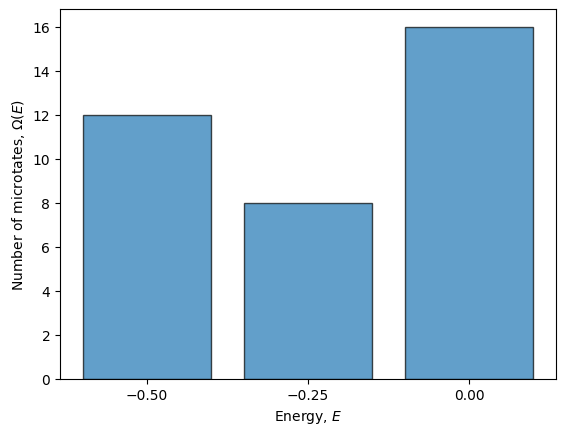

In [5]:
energies = []
for i in range(MicroState.total):
    energies.append(MicroState(i).energy)

fig, ax = plt.subplots()
ax.hist(energies, bins=[-0.625, -0.375, -0.125, 0.125], rwidth=0.8, alpha=0.7, edgecolor='k')
ax.set_xticks([-1/2, -1/4, 0])
ax.set_ylabel(r'Number of microtates, $\Omega(E)$')
ax.set_xlabel(r'Energy, $E$')

In [6]:
#canonical average energy:
kbT = 0.25
energies = np.array(energies)
E_avg2 = sum(energies*np.exp(-energies/kbT))/sum(np.exp(-energies/kbT))
print(E_avg2)

-0.39371062508852905


The results in this task (2) are the same as task 1.

### Task 3, N=4 and L=6

Number of microstates: 58905
check: 58905


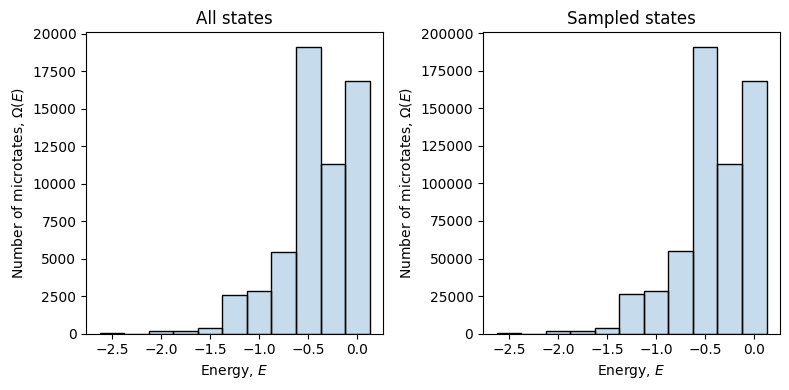

In [7]:
MicroState46 = make_microstate_factory(N=4, L=6)

#compute the total number of microstates with a binomial:
from math import factorial
binom = factorial(6*6)/factorial(6*6-4)/factorial(4)
print("Number of microstates:", int(binom))
print("check:", MicroState46.total)

Nsample = MicroState46.total*10
sampled_energies = []
all_energies = []
for i in range(MicroState46.total):
    all_energies.append(MicroState46(i).energy)
for _ in range(Nsample):
    sampled_energies.append(MicroState46().energy)

fig, axes = plt.subplots(1,2,figsize=(8,4))

# for energies, ax in zip([all_energies, sampled_energies], axes):
Nbins = 11
xmax = max(all_energies)
xmin = min(all_energies)
xwidth = (xmax-xmin) / (Nbins - 1)
xedges = np.linspace(xmin - xwidth/2, xmax + xwidth/2, Nbins+1)
xcenters = (xedges[:-1] + xedges[1:]) / 2

all_E_bars, _ = np.histogram(all_energies, bins=xedges)
sampled_E_bars, _ = np.histogram(sampled_energies, bins=xedges)

axes[0].bar(xcenters, all_E_bars, width=xwidth, facecolor='C0', alpha=0.25)
axes[0].bar(xcenters, all_E_bars, width=xwidth, facecolor='None', edgecolor='k')
axes[0].set_title('All states')

axes[1].bar(xcenters, sampled_E_bars, width=xwidth, facecolor='C0', alpha=0.25)
axes[1].bar(xcenters, sampled_E_bars, width=xwidth, facecolor='None', edgecolor='k')
axes[1].set_title('Sampled states')

for ax in axes:
    ax.set_ylabel(r'Number of microtates, $\Omega(E)$')
    ax.set_xlabel(r'Energy, $E$')

fig.tight_layout()



In [15]:
#canonical average energy:
kbT = 0.33
all_energies = np.array(all_energies)
sampled_energies = np.array(sampled_energies)
E_avg_exact = sum(all_energies*np.exp(-all_energies/kbT))/sum(np.exp(-all_energies/kbT))
E0 = sum(sampled_energies*np.exp(-sampled_energies/kbT))/sum(np.exp(-sampled_energies/kbT))
print(f"Exact canonical avg E: {E_avg_exact:.4f}")
print(f"Approximate canonical avg E: {E0:.4f}")

# using eq. 36:
Es = np.array(xcenters)
nEs = np.array(all_E_bars)
E0_eq36 = sum(Es*nEs*np.exp(-Es/kbT))/sum(nEs*np.exp(-Es/kbT))
print(f"\nApproximate canonical avg E: {E0_eq36:.4f}")

Exact canonical avg E: -1.2240
Approximate canonical avg E: -1.2348

Approximate canonical avg E: -1.2240


### Task 4, plot entropy

I have already collected all energies and a sample of energies 10 times the size.

The energies are already split into bins with energy spacing = 0.25

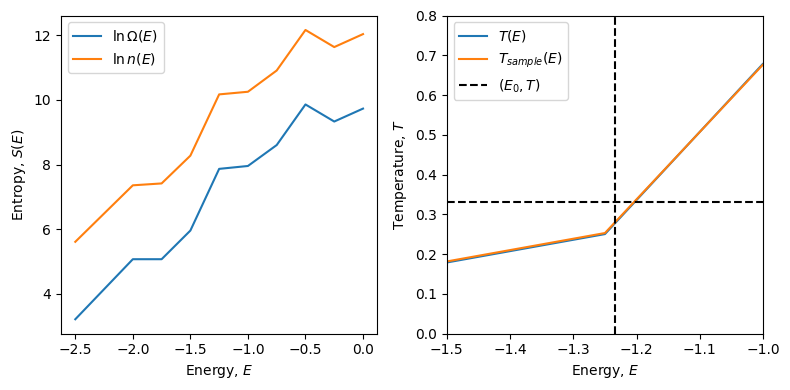

In [16]:
fig, axes = plt.subplots(1,2,figsize=(8,4))  

mask = all_E_bars>0
xcenters_all = xcenters[mask]
entropy_all = np.log(all_E_bars[mask])

mask = sampled_E_bars>0
xcenters_sampled = xcenters[mask]
entropy_sampled = np.log(sampled_E_bars[mask])

# entropy_all = np.where(all_E_bars > 0, np.log(all_E_bars), 0)
# entropy_sampled = np.where(sampled_E_bars > 0, np.log(sampled_E_bars), 0)

axes[0].plot(xcenters_all, entropy_all, label=r'$\ln\Omega(E)$')
axes[0].plot(xcenters_sampled, entropy_sampled, label=r'$\ln n(E)$')
axes[0].set_ylabel(r'Entropy, $S(E)$')

#thermal equilibrium between two systems is characterized by equality of their entropy slopes
T_all = 1/np.gradient(entropy_all, xcenters_all)
T_sampled = 1/np.gradient(entropy_sampled, xcenters_sampled)


axes[1].plot(xcenters_all, T_all, label=r'$T(E)$')
axes[1].plot(xcenters_sampled, T_sampled, label=r'$T_{sample}(E)$')
axes[1].axvline(E0, color='k', ls='--', label=r'$(E_0, T)$')#label=r'$\langle E \rangle_T$')
axes[1].axhline(kbT, color='k', ls='--')
axes[1].set_ylabel(r'Temperature, $T$')
axes[1].set_xlim(-1.5,-1)
axes[1].set_ylim(0,0.8)

for ax in axes:
    ax.set_xlabel(r'Energy, $E$')
    ax.legend()
fig.tight_layout()

The canonical average energy is normalized by the number of microstates, so the two averages are very similar.

The sampled histogram accurately reproduces the energy dependence of the multiplicity, so how come they differ vertically in the entropy figure?

For entropy they are not normalized by number of microstates, so:

$S(E)=\ln\Omega(E)$ and $\ln n(E)=\ln(10\Omega(E))=\ln\Omega(E)+\ln(10)$

Thus we see a vertical difference in entropy, but the overall shape is the same. 
This calls back to using different units of length for a probability distribution (W05C).

<!-- I should technically omit the bins where there are no states, since $\ln(0)=-\infty$. -->

<br>

*Relate the temperature near the equilibrium energy E0 found in Task 3 to the thermal energy kbT = 0.33 used there.*

*Explain why bins with very few counts can produce large fluctuations in the sampled temperature even when the sampled entropy curve appears reasonable.*

### Task 5

Number of microstates: 74974368
Approximate canonical avg E: -1.6475
Approximate canonical avg E: -1.7814
Approximate canonical avg E: -1.7237


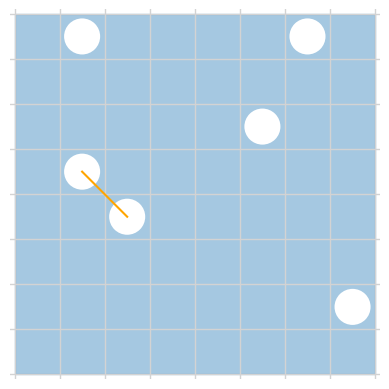

In [30]:
MicroState68 = make_microstate_factory(N=6, L=8)
print("Number of microstates:", MicroState68.total)

fig, ax = plt.subplots()
MicroState68().plot(ax)

Nsamples = [10_000, 100_000, 1_000_000]
sampled_energies_array = []
xcenters_array = []
for Nsample in Nsamples:
    sampled_energies = []
    for _ in range(Nsample):
        sampled_energies.append(MicroState68().energy)

    #canonical average energy:
    kbT = 0.4
    sampled_energies = np.array(sampled_energies)
    E0 = sum(sampled_energies*np.exp(-sampled_energies/kbT))/sum(np.exp(-sampled_energies/kbT))
    print(f"Approximate canonical avg E: {E0:.4f}")

    Nbins = 19
    xmax = 0
    xmin = -4.5
    xwidth = (xmax-xmin) / (Nbins - 1)
    xedges = np.linspace(xmin - xwidth/2, xmax + xwidth/2, Nbins+1)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    sampled_E_bars, _ = np.histogram(sampled_energies, bins=xedges)


    sampled_energies_array.append(sampled_E_bars)
    xcenters_array.append(xcenters)


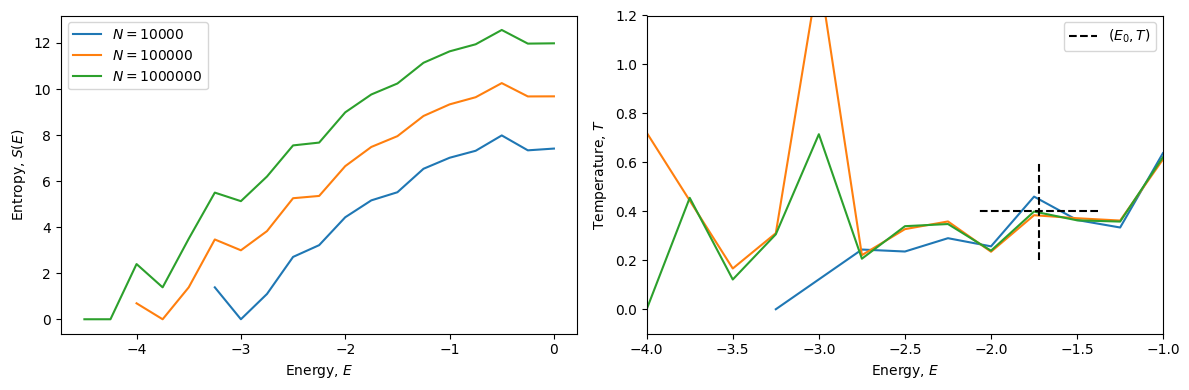

In [31]:
fig, axes = plt.subplots(1,2,figsize=(12,4))  

for ns, Es in zip(sampled_energies_array, xcenters_array):
    mask = ns>0
    Es = Es[mask]
    entropy = np.log(ns[mask])
    axes[0].plot(Es, entropy, label=f'$N={sum(ns)}$')
    axes[0].set_ylabel(r'Entropy, $S(E)$')

    T_sampled_68 = 1/np.gradient(entropy[entropy>0], Es[entropy>0]) 
    T_sampled_68 = [max(x, 0) for x in T_sampled_68]
    axes[1].plot(Es[entropy>0], T_sampled_68)


axes[1].vlines(E0, kbT-kbT*0.5, kbT+kbT*0.5, color='k', ls='--', label=r'$(E_0, T)$')#label=r'$\langle E \rangle_T$')
axes[1].hlines(kbT, E0-E0*0.2, E0+E0*0.2, color='k', ls='--')
axes[1].set_ylabel(r'Temperature, $T$')
axes[1].set_xlim(-4,-1)
axes[1].set_ylim(-0.1,1.2)

for ax in axes:
    ax.set_xlabel(r'Energy, $E$')
    ax.legend()
fig.tight_layout()

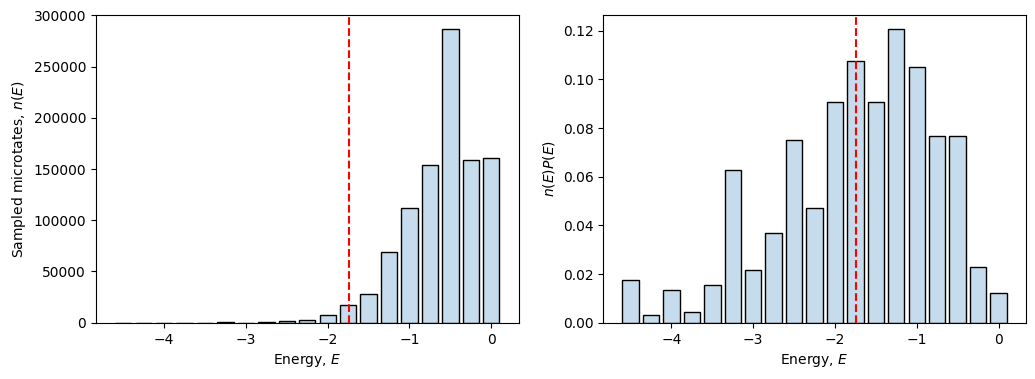

In [29]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

xcenters_68 = xcenters_array[-1]
sampled_E_bars_68 = sampled_energies_array[-1]
xmax = max(xcenters_68)
xmin = min(xcenters_68)
xwidth_68 = (xmax-xmin) / (Nbins - 1)

kbT = 0.4
axes[0].bar(xcenters_68, sampled_E_bars_68, width=xwidth_68*0.8, facecolor='C0', alpha=0.25)
axes[0].bar(xcenters_68, sampled_E_bars_68, width=xwidth_68*0.8, facecolor='None', edgecolor='k')
axes[0].axvline(E0, c='r', ls='--')
axes[0].set_ylabel(r'Sampled microtates, $n(E)$')
# axes[0].set_title('Sampled states')

#probabilites = n(E) * P(E) = n(E) * 1/Z exp(-E/kbT)
energies_68 = np.array(xcenters_68)
states_pr_energy_68 = np.array(sampled_E_bars_68)
Z = sum(states_pr_energy_68*np.exp(-energies_68/kbT))
probabilities = states_pr_energy_68/Z * np.exp(-energies_68/kbT)

axes[1].bar(xcenters_68, probabilities, width=xwidth_68*0.8, facecolor='C0', alpha=0.25)
axes[1].bar(xcenters_68, probabilities, width=xwidth_68*0.8, facecolor='None', edgecolor='k')
axes[1].axvline(E0, c='r', ls='--')
axes[1].set_ylabel(r'$n(E)P(E)$')

for ax in axes:
    ax.set_xlabel(r'Energy, $E$')


Use the plots to discuss whether this system represents a “decent” heat bath.

For et godt varmebad vil vi gerne have at entropien som function af energien, ved de energier vi er interesseret i at kigge på, er tilnærmelsesvis lineær. Dvs. at temperaturen skal være flad. Det ser vi at den tilnærmelsesvis er ved de mest sandsynlige energier. For lave energier bliver der ikke samplet særlig mange microstates, som giver stor statistisk usikkerhed.

For et uendligt stort heat bath er T lineær som function af energi. For et finite heat bath skulle den gerne være tilnærmelsesvis lineær inden for små energi-intervaller (som opgave A)


Number of microstates: 1192052400
Approximate canonical avg E: -1.1901


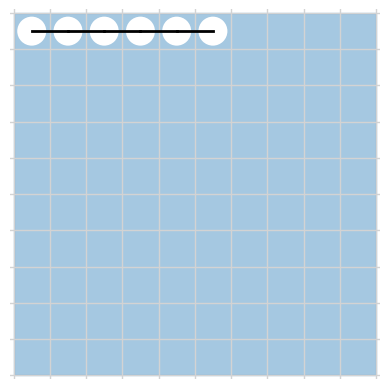

In [ ]:
MicroStateBIG = make_microstate_factory(N=6, L=8)
print("Number of microstates:", MicroStateBIG.total)

fig, ax = plt.subplots()
MicroStateBIG(0).plot(ax)

Nsamples = [3_000_000]
sampled_energies_array = []
xcenters_array = []
for Nsample in Nsamples:
    sampled_energies = []
    for _ in range(Nsample):
        sampled_energies.append(MicroStateBIG().energy)

    #canonical average energy:
    kbT = 0.4
    sampled_energies = np.array(sampled_energies)
    E0 = sum(sampled_energies*np.exp(-sampled_energies/kbT))/sum(np.exp(-sampled_energies/kbT))
    print(f"Approximate canonical avg E: {E0:.4f}")

    Nbins = 19
    xmax = 0
    xmin = -4.5
    xwidth = (xmax-xmin) / (Nbins - 1)
    xedges = np.linspace(xmin - xwidth/2, xmax + xwidth/2, Nbins+1)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    sampled_E_bars, _ = np.histogram(sampled_energies, bins=xedges)


    sampled_energies_array.append(sampled_E_bars)
    xcenters_array.append(xcenters)

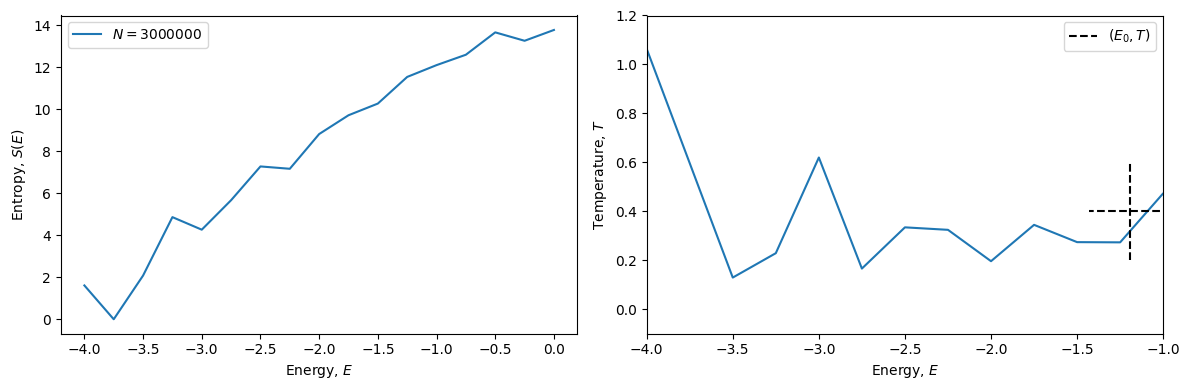

In [78]:
fig, axes = plt.subplots(1,2,figsize=(12,4))  

for ns, Es in zip(sampled_energies_array, xcenters_array):
    mask = ns>0
    Es = Es[mask]
    entropy = np.log(ns[mask])
    axes[0].plot(Es, entropy, label=f'$N={sum(ns)}$')
    axes[0].set_ylabel(r'Entropy, $S(E)$')

    T_sampled_68 = 1/np.gradient(entropy[entropy>0], Es[entropy>0]) 
    T_sampled_68 = [max(x, 0) for x in T_sampled_68]
    axes[1].plot(Es[entropy>0], T_sampled_68)


axes[1].vlines(E0, kbT-kbT*0.5, kbT+kbT*0.5, color='k', ls='--', label=r'$(E_0, T)$')#label=r'$\langle E \rangle_T$')
axes[1].hlines(kbT, E0-E0*0.2, E0+E0*0.2, color='k', ls='--')
axes[1].set_ylabel(r'Temperature, $T$')
axes[1].set_xlim(-4,-1)
axes[1].set_ylim(-0.1,1.2)

for ax in axes:
    ax.set_xlabel(r'Energy, $E$')
    ax.legend()
fig.tight_layout()

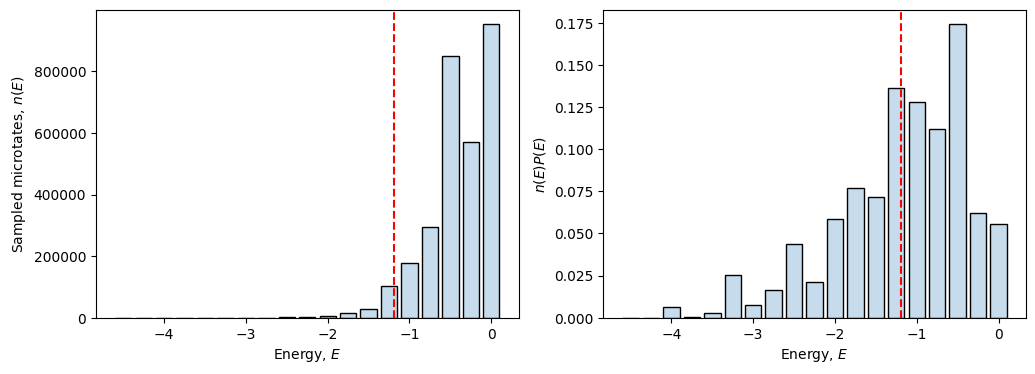

In [79]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

xcenters_68 = xcenters_array[-1]
sampled_E_bars_68 = sampled_energies_array[-1]
xmax = max(xcenters_68)
xmin = min(xcenters_68)
xwidth_68 = (xmax-xmin) / (Nbins - 1)

kbT = 0.4
axes[0].bar(xcenters_68, sampled_E_bars_68, width=xwidth_68*0.8, facecolor='C0', alpha=0.25)
axes[0].bar(xcenters_68, sampled_E_bars_68, width=xwidth_68*0.8, facecolor='None', edgecolor='k')
axes[0].axvline(E0, c='r', ls='--')
axes[0].set_ylabel(r'Sampled microtates, $n(E)$')
# axes[0].set_title('Sampled states')

#probabilites = n(E) * P(E) = n(E) * 1/Z exp(-E/kbT)
energies_68 = np.array(xcenters_68)
states_pr_energy_68 = np.array(sampled_E_bars_68)
Z = sum(states_pr_energy_68*np.exp(-energies_68/kbT))
probabilities = states_pr_energy_68/Z * np.exp(-energies_68/kbT)

axes[1].bar(xcenters_68, probabilities, width=xwidth_68*0.8, facecolor='C0', alpha=0.25)
axes[1].bar(xcenters_68, probabilities, width=xwidth_68*0.8, facecolor='None', edgecolor='k')
axes[1].axvline(E0, c='r', ls='--')
axes[1].set_ylabel(r'$n(E)P(E)$')

for ax in axes:
    ax.set_xlabel(r'Energy, $E$')


# W05F A small system in contact with a finite heat bath

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from week05 import make_microstate_factory

In [37]:
MicroState = make_microstate_factory (N=2, L=3)

kbT = 0.4
energies = []
for i in range(MicroState.total):
    energies.append(MicroState(i).energy)
energies = np.array(energies)
Z = sum(np.exp(-energies/kbT))
P = 1/Z * np.exp(-energies/kbT)

p_exact = [sum(P[energies==-0.5]), sum(P[energies==-0.25]), sum(P[energies==0.0])]

print("Probability of observing:\nE=-0.5:", p_exact[0])
print("E=-0.25:", p_exact[1])
print("E=0.0:", p_exact[2])

# canonical average energy
E_avg = sum(energies*np.exp(-energies/kbT))/sum(np.exp(-energies/kbT))
print(f"\nCanonical avg E: {E_avg:.4f}")


Probability of observing:
E=-0.5: 0.575093610752211
E=-0.25: 0.20521695174891505
E=0.0: 0.21968943749887385

Canonical avg E: -0.3389


Total number of microstates: 13442126049


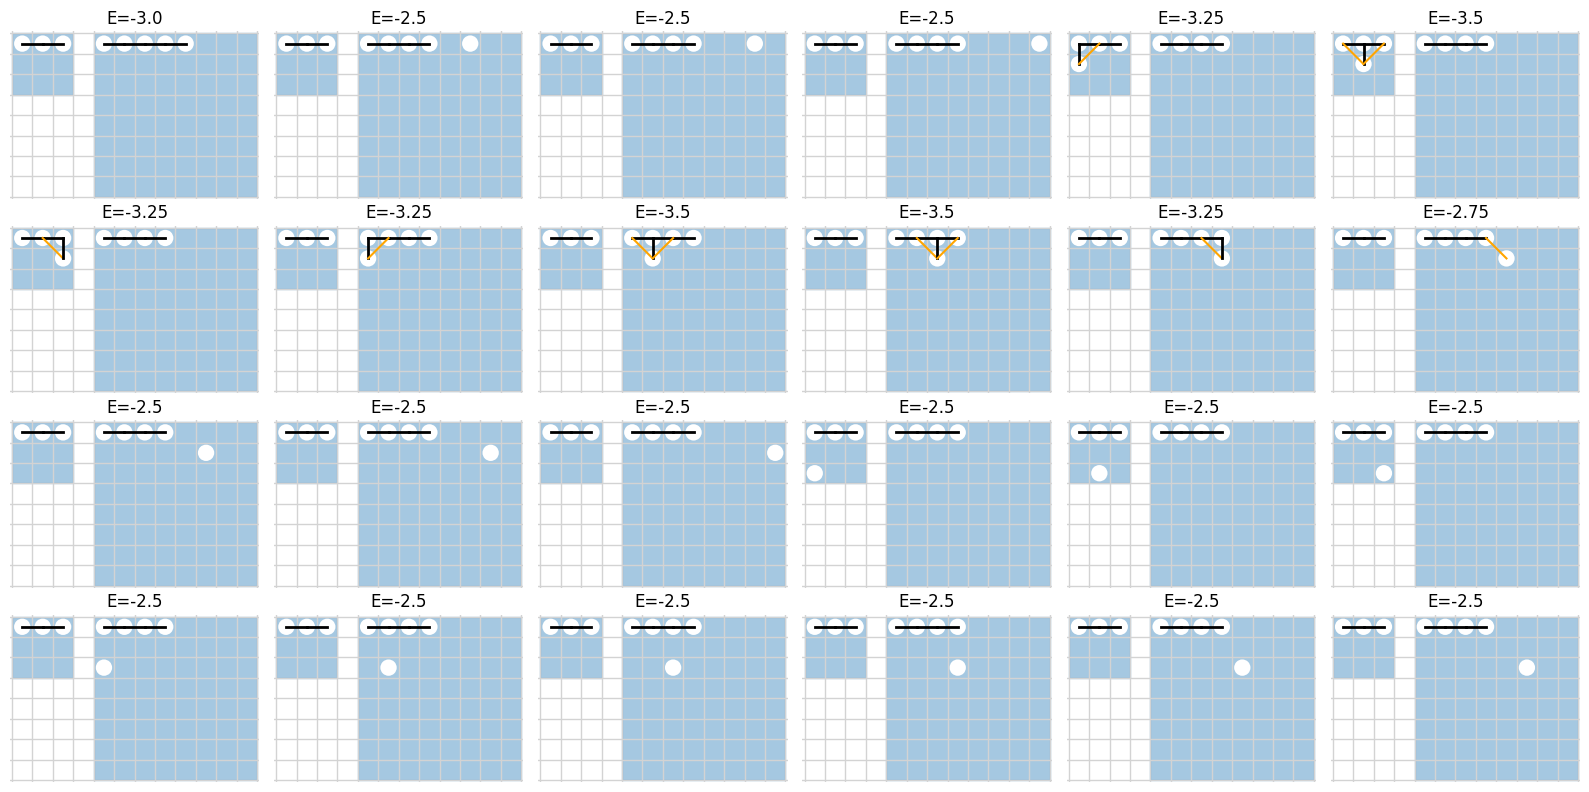

In [38]:
MicroStateBath = make_microstate_factory(N=8, L=3, B=8)

fig, axes = plt.subplots(4,6,figsize=(16,8))
for i, ax in enumerate(axes.flatten()):
    MicroStateBath(i).plot(ax)
    ax.set_title(f'E={MicroStateBath(i).energy}')
fig.tight_layout()

print("Total number of microstates:", MicroStateBath.total)

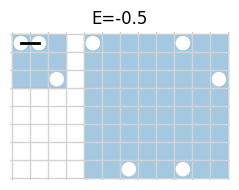

In [64]:
fig, ax = plt.subplots(figsize=(4,2))
MicroStateBath(15512542).plot(ax)
ax.set_title(f'E={MicroStateBath(15512542).energy}')
fig.tight_layout()

In [64]:
E_tot = -2
N_sub = 2

microstates = []
sub_energies = []
while len(microstates)<1000:
    i = int(np.random.uniform() * MicroStateBath.total)
    msb = MicroStateBath(i)
    if msb.Nsub == N_sub and msb.energy == E_tot:
        microstates.append(msb)
        sub_energies.append(msb.subsystem_energy)

Total number of microstates: 1000


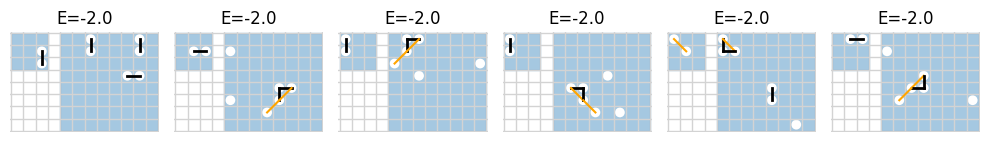

In [66]:
fig, axes = plt.subplots(1,6,figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
    microstates[i].plot(ax)
    ax.set_title(f'E={microstates[i].energy}')
fig.tight_layout()

print("Total number of microstates:", len(microstates))

In [71]:
# P0 = len([e for e in sub_energies if e==-0.5])/len(sub_energies)
# P1 = len([e for e in sub_energies if e==-0.25])/len(sub_energies)
# P2 = len([e for e in sub_energies if e==0.0])/len(sub_energies)

P0 = np.mean(sub_energies==-0.5)
P1 = np.mean(sub_energies==-0.25)
P2 = np.mean(sub_energies==0.0)

p_sampled = [P0, P1, P2]

print("Microcanonical probability of observing:\nE=-0.5:", P0)
print("E=-0.25:", P1)
print("E=0.0:", P2)

# approximate canonical average energy
E_avg_sample = np.mean(sub_energies)
# sub_energies = np.array(sub_energies)
# E_avg_sample = sum(sub_energies*np.exp(-sub_energies/kbT))/sum(np.exp(-sub_energies/kbT))
print(f"\nApproximate canonical avg E: {E_avg_sample:.4f}")

Microcanonical probability of observing:
E=-0.5: 0.564
E=-0.25: 0.218
E=0.0: 0.218

Approximate canonical avg E: -0.3365


Almost exactly the same as the exact probabilities of observing the 3 energies when not in a compound system (system + heat bath).

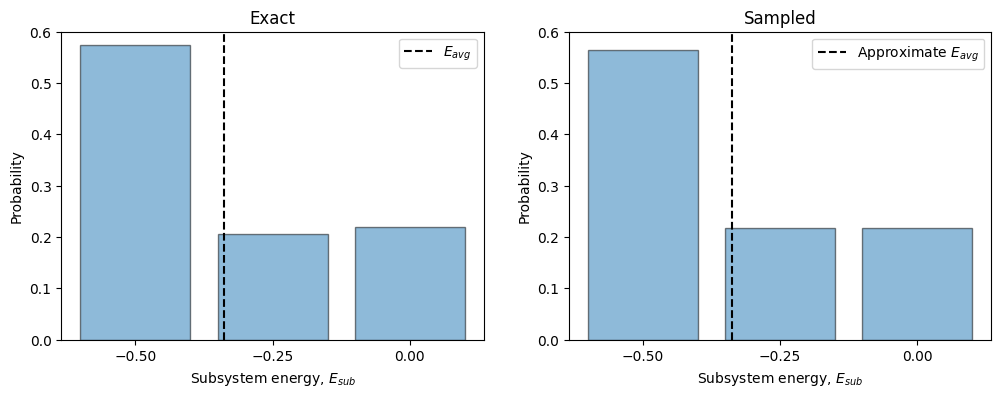

In [76]:
energies_unique = np.array([-0.5, -0.25, 0.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(energies_unique, p_exact, width=0.2, edgecolor='k', alpha=0.5)
axes[0].axvline(E_avg, label=r'$E_{avg}$', c='k', ls='--')
axes[0].set_title("Exact")

axes[1].bar(energies_unique, p_sampled, width=0.2, edgecolor='k', alpha=0.5)
axes[1].axvline(E_avg_sample, label=r'Approximate $E_{avg}$', c='k', ls='--')
axes[1].set_title("Sampled")

for ax in axes:
    ax.legend()
    ax.set_xticks(energies_unique)
    ax.set_ylabel("Probability")
    ax.set_xlabel(r"Subsystem energy, $E_{sub}$")
    ax.set_ylim(0, 0.6)

The sampled microcanonical statistics agree very well with the exact probabilites. Sampling a finite amount of microstates (in this case 1000) will result in statistical fluctuations that are inevitable. That's why they are not perfectly equal.

*Why can a subsystem of an isolated compound system approximately follow a canonical distribution?*

A small subsystem of a larger isolated system can effectively use the rest of the system as a heat bath. In the larger subsystem (heat bath), the number of possible microstates is much greater than for the smaller subsystem. Therefore, an exchange in energy for the small subsystem has a much greater relative effect than for the larger subsystem. That's why the 8x8 subsytem essentially works as a heat bath. 

<br>

From the lecture notes:

The total energy of a compound system, consisting of a small bath and a large bath:

$E_{tot}=E_s+E_b$   where $s$ denotes the system.

Let one microstate of the small system be $\mu$, and let the system be in that microstate, such that $E_s=E_\mu$, then:

$E_b = E_{tot}-E_\mu$

With this condition, the compatible microstates for the compound system are the configurations where the small system has energy $E_\mu$. That means, all microstates of the isolated compound system with energy $E_b$, i.e.:

$\Omega_{compound}(\mu)=\Omega_b(E_{tot}-E_\mu)$

All accessible states in the compound system is equially likely. Since $S_b=k_B\ln\Omega_b$, we can isolate and find:

$p_\mu\propto\exp\left[\frac{S_b(E_{tot}-E_\mu)}{k_B}\right]$

The entropy of a sufficiently large bath is approximately linear over the finite energy range exchanged with the small system, as we saw in exercise A. Introducing a mean energy of the small subsystem, the bath energy can be written as $E^*_b=E_{tot}-U$ (see eq. 5.61-5.63), and expanding around it for the entropy, we find:

$S_b(E_{tot}-E_\mu)\simeq S_b(E^*_b)-\frac{E_\mu-U}{T}$ 

assuming an ideal infinitely large bath. All higher order terms become negligible in this ideal limit. For a finite bath, they are small but nonzero. Notice that only $E_\mu/T$ depends on $\mu$, so the probability:

$p_\mu\propto\exp\left[-\frac{E_\mu}{k_BT}\right]$,      where all other terms are absorbed into normalization. Thus we find the Boltzmann distribution:

$p_\mu=\frac{1}{Z}\exp\left[-\frac{E_\mu}{k_BT}\right]$

When the observed system gains energy 𝐸𝜇, the bath loses that energy and its entropy changes by approximately −𝐸𝜇/𝑇. What remains unchanged in the ideal-bath limit is the bath’s entropy slope $\partial S_b/\partial E_b=1/T$, and therefore its temperature. A finite bath (as in this exercise of size 8x8) has a small but nonzero curvature, so its temperature changes slightly and the Boltzmann distribution  receives finite-bath corrections. **So, the small subsystem can approximately follow a canonical distribution.**

<br>

In perspective of the exercise: 

We start with 36 possible microstates for an isolated 3x3 system with N=2 atoms. We determine the exact probabilites of the system having the different energies simply by assuming they are equally likely and using the canonical distribution (Boltzmann distribution).

Now we put the small system together with a large system that act as a finite heat bath. We wish to sample the microstates in the compound system with 2 particles in the smaller subsystem, leaving 6 particles in the finite heat bath. From exercise D we found that 6 particles in an 8x8 bath had a temperature of $k_BT=0.4$ at $E \approx -1.7$. The canonical average energy (found in task 1 at $k_BT=0.4$) was $E_{avg}\approx-0.3$. Putting these energies together, we find that $E_{compound}\approx-2$ to get approximately $k_BT=0.4$ for the compound system as well. Thus we add this criterion to the sampling. Finally, we count the microstates of each energy (-0.5, -0.25, 0.0) and normalize by all sampled microstates. We find that it almost exactly follows the canonical distribution from the first part of the exercise.